# Policy Gradient Demo: REINFORCE and Actor-Critic

This notebook focuses on **policy-based methods** for the crawler with **continuous actions**.

| Demo | Method | Main idea |
|------|--------|-----------|
| 5 | REINFORCE | Directly optimize a stochastic policy for continuous torques |
| 6 | Baseline choices | Compare constant and time-dependent baselines |
| 7 | Actor-Critic | Learn a state-dependent baseline $V(s)$ |

We keep the **same crawler** and the **same 4D observation** as before:
- arm angle
- hand angle
- arm angular velocity
- hand angular velocity

But now the policy directly outputs **continuous 2D torques**:

$$\pi_\theta(s) \rightarrow a \in \mathbb{R}^2$$

The progression in this notebook is:
1. Train a continuous stochastic policy with **REINFORCE**
2. Compare **baseline choices** for reducing variance
3. Learn a **state-dependent baseline** with **Actor-Critic**

In [44]:
# Setup - run this first
!pip install -q mujoco

import numpy as np
import mujoco
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
from pathlib import Path
import time
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

print(f'MuJoCo version: {mujoco.__version__}')
print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Setup complete!')



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
MuJoCo version: 3.6.0
PyTorch version: 2.11.0
Device: cpu
Setup complete!


In [45]:
# ============================================================
# Crawler Environment (same as demo_crawler_rl.ipynb)
# ============================================================

CRAWLER_XML = """
<mujoco model="crawler2d">
  <compiler angle="degree" inertiafromgeom="true"/>
  <option timestep="0.005" gravity="0 0 -9.81" integrator="RK4"/>

  <default>
    <geom conaffinity="1" condim="3" friction="1.5 0.5 0.1" density="1000"/>
    <joint armature="0.1" damping="0.5"/>
  </default>

  <asset>
    <texture type="2d" name="grid" builtin="checker" width="512" height="512"
             rgb1="0.7 0.9 0.7" rgb2="0.6 0.85 0.6"/>
    <material name="grid" texture="grid" texrepeat="8 8"/>
  </asset>

  <worldbody>
    <light diffuse="0.8 0.8 0.8" pos="0 -2 3" dir="0 0.5 -1"/>
    <geom name="floor" type="plane" size="50 1 0.1" material="grid"/>

    <geom name="origin" type="box" size="0.01 0.15 0.002" pos="0 0 0.001" rgba="0.1 0.1 0.8 0.7" contype="0" conaffinity="0"/>
    <geom name="ruler_m4" type="box" size="0.006 0.12 0.002" pos="-2.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_m3" type="box" size="0.003 0.08 0.001" pos="-1.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_m2" type="box" size="0.006 0.12 0.002" pos="-1.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_m1" type="box" size="0.003 0.08 0.001" pos="-0.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_1" type="box" size="0.003 0.08 0.001" pos="0.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_2" type="box" size="0.006 0.12 0.002" pos="1.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_3" type="box" size="0.003 0.08 0.001" pos="1.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_4" type="box" size="0.006 0.12 0.002" pos="2.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_5" type="box" size="0.003 0.08 0.001" pos="2.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_6" type="box" size="0.006 0.12 0.002" pos="3.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_7" type="box" size="0.003 0.08 0.001" pos="3.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_8" type="box" size="0.006 0.12 0.002" pos="4.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_9" type="box" size="0.003 0.08 0.001" pos="4.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_10" type="box" size="0.006 0.12 0.002" pos="5.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_11" type="box" size="0.003 0.08 0.001" pos="5.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_12" type="box" size="0.006 0.12 0.002" pos="6.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_13" type="box" size="0.003 0.08 0.001" pos="6.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_14" type="box" size="0.006 0.12 0.002" pos="7.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_15" type="box" size="0.003 0.08 0.001" pos="7.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_16" type="box" size="0.006 0.12 0.002" pos="8.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_17" type="box" size="0.003 0.08 0.001" pos="8.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_18" type="box" size="0.006 0.12 0.002" pos="9.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_19" type="box" size="0.003 0.08 0.001" pos="9.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_20" type="box" size="0.006 0.12 0.002" pos="10.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>

    <camera name="side" pos="0 -0.8 0.25" xyaxes="1 0 0 0 0.3 1" mode="trackcom"/>

    <body name="torso" pos="0 0 0.035">
      <joint name="root_x" type="slide" axis="1 0 0"/>
      <joint name="root_z" type="slide" axis="0 0 1"/>
      <joint name="root_rot" type="hinge" axis="0 1 0"/>

      <geom name="torso_geom" type="box" size="0.08 0.035 0.025"
            rgba="0.3 0.75 0.3 1" density="3000"/>

      <body name="arm" pos="0.08 0 0.01">
        <joint name="arm_joint" type="hinge" axis="0 1 0"
               range="-70 70" limited="true"/>
        <geom name="arm_geom" type="capsule" size="0.012"
              fromto="0 0 0 0.12 0 0" rgba="0.95 0.7 0.1 1"/>

        <body name="hand" pos="0.12 0 0">
          <joint name="hand_joint" type="hinge" axis="0 1 0"
                 range="-70 70" limited="true"/>
          <geom name="hand_geom" type="capsule" size="0.008"
                fromto="0 0 0 0.08 0 0" rgba="0.9 0.15 0.15 1"/>
        </body>
      </body>
    </body>
  </worldbody>

  <actuator>
    <motor name="arm_motor" joint="arm_joint" ctrllimited="true"
           ctrlrange="-1 1" gear="5"/>
    <motor name="hand_motor" joint="hand_joint" ctrllimited="true"
           ctrlrange="-1 1" gear="3"/>
  </actuator>
</mujoco>
"""


class CrawlerEnv:
    """2D MuJoCo crawler with 2 actuated joints.

    State:  4D continuous (arm angle, hand angle, arm vel, hand vel)
    Action: 2D continuous torque in [-1, 1]
    Reward: forward (x) velocity
    """

    def __init__(self, max_steps=500, frame_skip=4):
        self.model = mujoco.MjModel.from_xml_string(CRAWLER_XML)
        self.data = mujoco.MjData(self.model)
        self.max_steps = max_steps
        self.frame_skip = frame_skip
        self.steps = 0
        self.obs_dim = 4
        self.act_dim = 2

    def get_obs(self):
        arm_a, hand_a = self.data.qpos[3], self.data.qpos[4]
        arm_v, hand_v = self.data.qvel[3], self.data.qvel[4]
        return np.array([arm_a, hand_a, arm_v, hand_v], dtype=np.float32)

    def reset(self):
        mujoco.mj_resetData(self.model, self.data)
        self.data.qpos[3] = np.random.uniform(-0.1, 0.1)
        self.data.qpos[4] = np.random.uniform(-0.1, 0.1)
        mujoco.mj_forward(self.model, self.data)
        self.steps = 0
        return self.get_obs()

    def step(self, ctrl):
        x_before = self.data.qpos[0]
        self.data.ctrl[:] = np.clip(ctrl, -1, 1)
        for _ in range(self.frame_skip):
            mujoco.mj_step(self.model, self.data)
        x_after = self.data.qpos[0]
        dt = self.frame_skip * self.model.opt.timestep
        reward = (x_after - x_before) / dt
        self.steps += 1
        truncated = self.steps >= self.max_steps
        return self.get_obs(), reward, False, truncated, {'x': x_after}


print(f'Environment: obs_dim={CrawlerEnv().obs_dim}, act_dim={CrawlerEnv().act_dim}')
print('Actions are now CONTINUOUS 2D torques in [-1, 1] -- no more discrete action table!')

Environment: obs_dim=4, act_dim=2
Actions are now CONTINUOUS 2D torques in [-1, 1] -- no more discrete action table!


In [46]:
# ============================================================
# Visualization helpers (same as previous notebook)
# ============================================================

eval_results = {}


def render_episode(env, policy_fn, max_steps=500, cam_name='side'):
    """Roll out a policy. Returns (frames, distance, total_reward)."""
    renderer = mujoco.Renderer(env.model, height=320, width=560)
    frames = []
    obs = env.reset()
    total_reward = 0
    for _ in range(max_steps):
        renderer.update_scene(env.data, camera=cam_name)
        frames.append(renderer.render().copy())
        ctrl = policy_fn(obs)
        obs, reward, terminated, truncated, _ = env.step(ctrl)
        total_reward += reward
        if terminated or truncated:
            break
    dist = float(env.data.qpos[0])
    renderer.close()
    return frames, dist, total_reward


def eval_policy(env, policy_fn, label, max_steps=500):
    """Run a 10s rollout, render video, print distance, store result."""
    frames, dist, total_reward = render_episode(env, policy_fn, max_steps=max_steps)
    print(f'{label}: traveled {dist:.2f}m in 10s  (episode reward: {total_reward:.1f})')
    eval_results[label] = dist
    return frames, dist, total_reward


def show_video(frames, fps=30, title=None):
    fig, ax = plt.subplots(figsize=(8, 4))
    if title:
        ax.set_title(title, fontsize=14)
    ax.axis('off')
    im = ax.imshow(frames[0])
    def update(i):
        im.set_data(frames[i])
        return [im]
    anim = animation.FuncAnimation(fig, update, frames=len(frames),
                                   interval=1000/fps, blit=True)
    plt.close()
    return HTML(anim.to_html5_video())


def plot_rewards(rewards, window=50, title='Training Progress', ax=None, color='steelblue', label=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(rewards, alpha=0.15, color=color)
    if len(rewards) >= window:
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), smoothed, color=color, linewidth=2, label=label)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return ax


def plot_eval_comparison(results_dict, title='Policy Comparison: Distance Traveled in 10s'):
    labels = list(results_dict.keys())
    dists = list(results_dict.values())
    colors = ['#d9534f' if d < 0.5 else '#5bc0de' if d < 1.5 else '#5cb85c' for d in dists]

    fig, ax = plt.subplots(figsize=(10, max(3, len(labels) * 0.5 + 1)))
    bars = ax.barh(labels, dists, color=colors, edgecolor='white', height=0.6)
    ax.set_xlabel('Distance (m)')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='gray', linewidth=0.5)
    for bar, d in zip(bars, dists):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{d:.2f}m', va='center', fontsize=11)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


def stack_histories(histories):
    arrays = [np.asarray(h, dtype=np.float32) for h in histories if len(h) > 0]
    if not arrays:
        return np.zeros((0, 0), dtype=np.float32)
    min_len = min(len(h) for h in arrays)
    return np.stack([h[:min_len] for h in arrays], axis=0)


def smooth_histories(histories, window=40):
    data = stack_histories(histories)
    if data.size == 0:
        return np.array([], dtype=np.int32), np.zeros((0, 0), dtype=np.float32)
    if data.shape[1] < window:
        return np.arange(data.shape[1]), data
    smoothed = np.array([
        np.convolve(h, np.ones(window)/window, mode='valid')
        for h in data
    ])
    x = np.arange(window - 1, data.shape[1])
    return x, smoothed


def plot_seed_average(ax, histories, *, color, label, window=40, alpha=0.15):
    x, smoothed = smooth_histories(histories, window=window)
    if smoothed.size == 0:
        return
    mean = smoothed.mean(axis=0)
    std = smoothed.std(axis=0)
    ax.plot(x, mean, color=color, linewidth=2, label=label)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=alpha)


def summarize_final_window(histories, tail=50):
    values = [float(np.mean(np.asarray(h)[-tail:])) for h in histories if len(h) > 0]
    if not values:
        return 0.0, 0.0
    return float(np.mean(values)), float(np.std(values))


# ============================================================
# Checkpoint helpers
# ============================================================

CHECKPOINT_DIR = Path('saved_checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)
LATEST_CHECKPOINT_PATH = CHECKPOINT_DIR / 'latest_pg_training.pt'

# Manually set this to True if you want to ignore cached files and retrain.
FORCE_RETRAIN = False


def checkpoint_slug(kind, meta):
    parts = [kind]
    for key in ('demo', 'variant', 'baseline', 'seed', 'n_episodes'):
        if key in meta and meta[key] is not None:
            parts.append(str(meta[key]))
    raw = '_'.join(parts)
    return ''.join(ch if ch.isalnum() or ch in '._-' else '_' for ch in raw)


def checkpoint_path_for(kind, meta):
    return CHECKPOINT_DIR / f'{checkpoint_slug(kind, meta)}.pt'


def save_pg_checkpoint(payload):
    payload = dict(payload)
    payload['saved_at'] = time.strftime('%Y-%m-%d %H:%M:%S')
    meta = payload.get('meta', {})
    path = checkpoint_path_for(payload.get('kind', 'pg'), meta)
    torch.save(payload, path)
    torch.save(payload, LATEST_CHECKPOINT_PATH)
    print(f'Saved checkpoint -> {path}')
    print(f'Updated latest checkpoint -> {LATEST_CHECKPOINT_PATH}')
    return path


def load_pg_checkpoint(path, verbose=True):
    if not path.exists():
        return None
    payload = torch.load(path, map_location='cpu', weights_only=False)
    if verbose:
        print(f'Found checkpoint <- {path}')
        print(f"  label={payload.get('label', 'unknown')} | kind={payload.get('kind', 'unknown')}")
    return payload


def checkpoint_matches(payload, *, kind, required_meta, ignore_keys=()):
    if payload is None or payload.get('kind') != kind:
        return False
    meta = payload.get('meta', {})
    ignored = set(ignore_keys)
    return all(meta.get(k) == v for k, v in required_meta.items() if k not in ignored)


def find_compatible_pg_checkpoint(kind, required_meta, *, ignore_keys=('n_episodes',)):
    candidates = []
    for path in sorted(CHECKPOINT_DIR.glob(f'{kind}*.pt')):
        if path == LATEST_CHECKPOINT_PATH:
            continue
        payload = load_pg_checkpoint(path, verbose=False)
        if not checkpoint_matches(payload, kind=kind, required_meta=required_meta,
                                 ignore_keys=ignore_keys):
            continue
        meta = payload.get('meta', {})
        n_episodes = int(meta.get('n_episodes', -1) or -1)
        candidates.append((n_episodes, path, payload))

    if not candidates:
        return None, None

    candidates.sort(key=lambda item: (item[0], str(item[1])))
    _, path, payload = candidates[-1]
    return payload, path


def maybe_load_pg_checkpoint(*, kind, obs_dim, act_dim, hidden=64, label,
                             extra_meta=None, with_critic=False):
    if FORCE_RETRAIN:
        print(f'FORCE_RETRAIN=True for {label}; ignoring saved checkpoint.')
        return None

    required_meta = {
        'obs_dim': int(obs_dim),
        'act_dim': int(act_dim),
        'hidden': int(hidden),
    }
    if extra_meta:
        required_meta.update(extra_meta)

    matched_path = None
    specific_path = checkpoint_path_for(kind, required_meta)
    payload = load_pg_checkpoint(specific_path, verbose=False)
    if checkpoint_matches(payload, kind=kind, required_meta=required_meta):
        matched_path = specific_path
    else:
        payload = load_pg_checkpoint(LATEST_CHECKPOINT_PATH, verbose=False)
        if checkpoint_matches(payload, kind=kind, required_meta=required_meta):
            matched_path = LATEST_CHECKPOINT_PATH

    if matched_path is None and 'n_episodes' in required_meta:
        payload, matched_path = find_compatible_pg_checkpoint(kind, required_meta)
        if payload is not None:
            saved_episodes = payload.get('meta', {}).get('n_episodes', 'unknown')
            print(
                f"Loaded compatible checkpoint for {label} from {matched_path.name} "
                f"(saved n_episodes={saved_episodes}, requested {required_meta['n_episodes']})."
            )

    if matched_path is None:
        return None

    policy = GaussianPolicy(obs_dim, act_dim, hidden).to(device)
    policy.load_state_dict(payload['policy_state_dict'])
    policy.eval()

    rewards = list(payload.get('rewards', []))
    extras = payload.get('extras', {})
    print(f'Loaded checkpoint for {label}; skipping retraining.')

    if with_critic:
        critic_hidden = int(required_meta.get('critic_hidden', hidden))
        critic = ValueNetwork(obs_dim, critic_hidden).to(device)
        critic.load_state_dict(payload['critic_state_dict'])
        critic.eval()
        return policy, critic, rewards, extras

    return policy, rewards, extras


---
## Demo 5: REINFORCE with continuous actions

Instead of learning action values and deriving a policy from them, **policy gradient** directly optimizes the policy itself:
- The policy network **directly outputs** continuous torques
- We parametrize a **Gaussian distribution** over actions: the network outputs the mean $\mu(s)$, and we sample $a \sim \mathcal{N}(\mu(s), \sigma^2)$
- Training: collect full episodes, then **increase the probability of actions that led to high reward**

This is the **REINFORCE** algorithm (Williams, 1992):

$$\nabla_\theta J(\theta) = \mathbb{E}\left[\sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t\right]$$

where $G_t = \sum_{t'=t}^{T} \gamma^{t'-t} r_{t'}$ is the return from timestep $t$.

**Same crawler, same 4D state — but now with continuous 2D torque output.**

In [58]:
# ============================================================
# REINFORCE (Vanilla Policy Gradient)
# ============================================================

class GaussianPolicy(nn.Module):
    """Policy network that outputs mean of a Gaussian. std is a learnable parameter."""
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, act_dim), nn.Tanh()  # output in [-1, 1]
        )
        # Learnable log-std (start at log(0.5) ~= -0.69)
        self.log_std = nn.Parameter(torch.full((act_dim,), -0.7))

    def forward(self, obs):
        mu = self.net(obs)
        std = self.log_std.exp()
        return mu, std

    def get_action(self, obs):
        """Sample an action and return (action, log_prob)."""
        mu, std = self.forward(obs)
        dist = Normal(mu, std)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        return action.clamp(-1, 1), log_prob

    def evaluate(self, obs, actions):
        """Compute log_prob of given actions (for batched computation)."""
        mu, std = self.forward(obs)
        dist = Normal(mu, std)
        return dist.log_prob(actions).sum(dim=-1)


def train_reinforce(env, n_episodes=500, gamma=0.99, lr=3e-4, hidden=64,
                    verbose=True, seed=None, checkpoint_label=None,
                    checkpoint_meta=None):
    """Train REINFORCE. Returns (policy, rewards_list)."""
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    policy = GaussianPolicy(env.obs_dim, env.act_dim, hidden).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    rewards_history = []
    adv_std_history = []

    t0 = time.time()
    for ep in range(n_episodes):
        obs = env.reset()
        log_probs = []
        rewards = []

        while True:
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            action, log_prob = policy.get_action(obs_t)
            act_np = action.squeeze(0).cpu().detach().numpy()

            next_obs, reward, terminated, truncated, _ = env.step(act_np)
            log_probs.append(log_prob)
            rewards.append(reward)
            obs = next_obs
            if terminated or truncated:
                break

        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns).to(device)
        adv_std_history.append(float(returns.std().item()) if len(returns) > 1 else 0.0)

        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        log_probs_t = torch.stack(log_probs).squeeze()
        loss = -(log_probs_t * returns).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward = sum(rewards)
        rewards_history.append(total_reward)

        if verbose and (ep + 1) % 100 == 0:
            avg = np.mean(rewards_history[-50:])
            std_val = policy.log_std.exp().mean().item()
            print(f'  Episode {ep+1:4d} | Avg reward: {avg:7.1f} | std: {std_val:.3f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')

    if checkpoint_label is not None:
        meta = {
            'obs_dim': int(env.obs_dim),
            'act_dim': int(env.act_dim),
            'hidden': int(hidden),
        }
        if checkpoint_meta:
            meta.update(checkpoint_meta)
        save_pg_checkpoint({
            'kind': 'reinforce',
            'label': checkpoint_label,
            'meta': meta,
            'policy_state_dict': policy.state_dict(),
            'rewards': np.asarray(rewards_history, dtype=np.float32),
            'extras': {
                'adv_std_history': np.asarray(adv_std_history, dtype=np.float32),
            },
        })

    return policy, rewards_history


In [59]:
# ---------- Demo 5: REINFORCE on the crawler ----------
print('=== Demo 5: REINFORCE with continuous actions ===')
print(f'State: 4D continuous (arm angle, hand angle, arm vel, hand vel)')
print(f'Actions: 2D CONTINUOUS torques in [-1, 1]')
print(f'Policy: Gaussian (neural net outputs mean, learnable std)\n')

env_pg = CrawlerEnv()
reinforce_meta = {
    'demo': '5',
    'variant': 'reinforce',
    'n_episodes': 4500,
}
latest = maybe_load_pg_checkpoint(
    kind='reinforce',
    obs_dim=env_pg.obs_dim,
    act_dim=env_pg.act_dim,
    hidden=64,
    label='Demo 5: REINFORCE',
    extra_meta=reinforce_meta,
)
if latest is None:
    policy_reinforce, rewards_reinforce = train_reinforce(
        env_pg,
        n_episodes=4500,
        lr=3e-4,
        checkpoint_label='Demo 5: REINFORCE',
        checkpoint_meta=reinforce_meta,
    )
else:
    policy_reinforce, rewards_reinforce, _ = latest


=== Demo 5: REINFORCE with continuous actions ===
State: 4D continuous (arm angle, hand angle, arm vel, hand vel)
Actions: 2D CONTINUOUS torques in [-1, 1]
Policy: Gaussian (neural net outputs mean, learnable std)

  Episode  100 | Avg reward:     2.0 | std: 0.497
  Episode  200 | Avg reward:    19.9 | std: 0.494
  Episode  300 | Avg reward:    22.8 | std: 0.492
  Episode  400 | Avg reward:    24.3 | std: 0.490
  Episode  500 | Avg reward:    24.7 | std: 0.488
  Episode  600 | Avg reward:    24.7 | std: 0.487
  Episode  700 | Avg reward:    25.1 | std: 0.486
  Episode  800 | Avg reward:    25.2 | std: 0.487
  Episode  900 | Avg reward:    24.8 | std: 0.487
  Episode 1000 | Avg reward:    24.6 | std: 0.488
  Episode 1100 | Avg reward:    25.3 | std: 0.487
  Episode 1200 | Avg reward:    25.5 | std: 0.488
  Episode 1300 | Avg reward:    25.2 | std: 0.484
  Episode 1400 | Avg reward:    25.4 | std: 0.483
  Episode 1500 | Avg reward:    25.5 | std: 0.482
  Episode 1600 | Avg reward:    25.

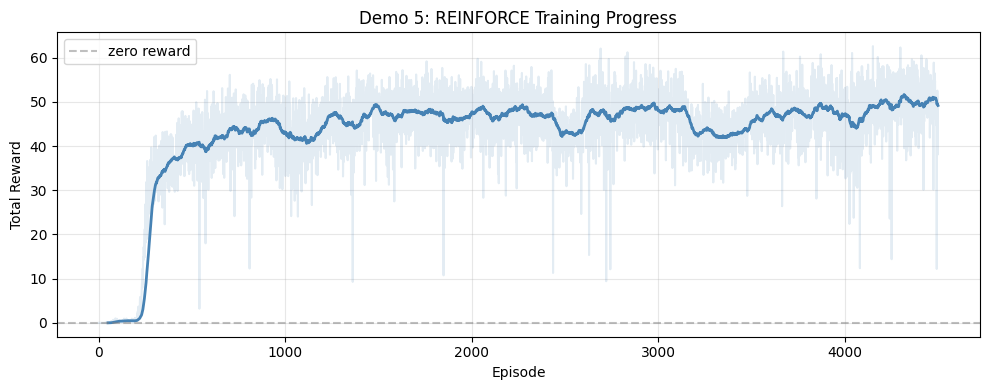


Final avg reward (last 50 episodes): 49.2
Note: actions are CONTINUOUS — no discretization needed!


In [11]:
# Training curve
fig, ax = plt.subplots(figsize=(10, 4))
plot_rewards(rewards_reinforce, title='Demo 5: REINFORCE Training Progress', ax=ax)
ax.axhline(y=0, color='gray', ls='--', alpha=0.5, label='zero reward')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nFinal avg reward (last 50 episodes): {np.mean(rewards_reinforce[-50:]):.1f}')
print(f'Note: actions are CONTINUOUS — no discretization needed!')

In [60]:
# 10-second rollout of the REINFORCE policy
env_eval = CrawlerEnv()

def reinforce_policy(obs):
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        mu, _ = policy_reinforce(obs_t)
        return mu.squeeze(0).cpu().numpy()

frames_pg, dist_pg, _ = eval_policy(env_eval, reinforce_policy, 'Demo 5: REINFORCE')
show_video(frames_pg, title=f'REINFORCE — {dist_pg:.2f}m in 10s (continuous actions!)')

Demo 5: REINFORCE: traveled 1.00m in 10s  (episode reward: 50.2)


---
## Demo 6: Baseline choices and variance reduction

The variance problem is not only that different random seeds end up in different places. You can already see it **inside one run**: the policy updates swing around because the weights $G_t$ are noisy.

A baseline reduces this variance by replacing $G_t$ with $G_t - b_t$:

$$
\nabla_\theta J(\theta) = \mathbb{E}\left[\sum_t \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot (G_t - b_t)\right]
$$

We compare three cases with the **same hyperparameters** and average over **10 random seeds**:
1. **Vanilla REINFORCE**: no baseline, so
   $$b_t = 0$$
2. **Constant baseline**: one scalar baseline for the whole episode,
   $$b_t = b = \mathbb{E}[R(\tau)] \approx \frac{1}{m}\sum_{i=1}^{m} R(\tau^{(i)})$$
3. **Time-dependent baseline**: one running-average baseline per timestep,
   $$b_t = \mathbb{E}[G_t] \approx \frac{1}{m}\sum_{i=1}^{m} G_t^{(i)}$$

To make the variance reduction visible, we plot both:
- the **mean training reward across seeds**
- the **mean std of the raw policy weights** $G_t - b_t$ before normalization (a direct variance proxy)

The shaded band in the plots is one standard deviation across seeds.


In [34]:
# ---------- Demo 6: Baseline comparison averaged over 10 seeds ----------
def discounted_returns(rewards, gamma=0.99):
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return np.array(returns, dtype=np.float32)


def train_reinforce_with_baseline(env, baseline='none', n_episodes=500, gamma=0.99,
                                  lr=3e-4, hidden=64, verbose=True, seed=None,
                                  checkpoint_label=None, checkpoint_meta=None):
    """Train REINFORCE with a hand-designed baseline. Returns (policy, rewards, adv_std)."""
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    policy = GaussianPolicy(env.obs_dim, env.act_dim, hidden).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    rewards_history = []
    adv_std_history = []
    running_return_mean = 0.0
    time_baseline_sum = []
    time_baseline_count = []

    t0 = time.time()
    for ep in range(n_episodes):
        obs = env.reset()
        log_probs = []
        rewards = []

        while True:
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            action, log_prob = policy.get_action(obs_t)
            act_np = action.squeeze(0).cpu().detach().numpy()

            next_obs, reward, terminated, truncated, _ = env.step(act_np)
            log_probs.append(log_prob)
            rewards.append(reward)
            obs = next_obs
            if terminated or truncated:
                break

        returns_np = discounted_returns(rewards, gamma)
        baseline_np = np.zeros_like(returns_np)

        if baseline == 'constant' and ep > 0:
            baseline_np[:] = running_return_mean
        elif baseline == 'time':
            for t in range(len(returns_np)):
                if t < len(time_baseline_sum) and time_baseline_count[t] > 0:
                    baseline_np[t] = time_baseline_sum[t] / time_baseline_count[t]

        advantages_np = returns_np - baseline_np
        adv_std_history.append(float(np.std(advantages_np)) if len(advantages_np) > 1 else 0.0)

        advantages = torch.FloatTensor(advantages_np).to(device)
        if len(advantages) > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        log_probs_t = torch.stack(log_probs).squeeze()
        loss = -(log_probs_t * advantages).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward = sum(rewards)
        rewards_history.append(total_reward)

        if baseline == 'constant':
            episode_return = float(returns_np[0])
            running_return_mean = (running_return_mean * ep + episode_return) / (ep + 1)
        elif baseline == 'time':
            while len(time_baseline_sum) < len(returns_np):
                time_baseline_sum.append(0.0)
                time_baseline_count.append(0)
            for t, G in enumerate(returns_np):
                time_baseline_sum[t] += float(G)
                time_baseline_count[t] += 1

        if verbose and (ep + 1) % 100 == 0:
            avg_r = np.mean(rewards_history[-50:])
            avg_std = np.mean(adv_std_history[-50:])
            print(f'  Episode {ep+1:4d} | Avg reward: {avg_r:7.1f} | avg std(G-b): {avg_std:7.2f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')

    if checkpoint_label is not None:
        meta = {
            'obs_dim': int(env.obs_dim),
            'act_dim': int(env.act_dim),
            'hidden': int(hidden),
            'baseline': baseline,
        }
        if checkpoint_meta:
            meta.update(checkpoint_meta)
        save_pg_checkpoint({
            'kind': 'reinforce_baseline',
            'label': checkpoint_label,
            'meta': meta,
            'policy_state_dict': policy.state_dict(),
            'rewards': np.asarray(rewards_history, dtype=np.float32),
            'extras': {
                'adv_std_history': np.asarray(adv_std_history, dtype=np.float32),
            },
        })

    return policy, rewards_history, adv_std_history


print('=== Demo 6: Baseline choices averaged over 10 seeds ===\n')

compare_seeds = list(range(10))
compare_episodes = 600
baseline_specs = [
    ('Vanilla (no baseline)', 'none', 'tab:orange'),
    ('Constant baseline', 'constant', 'tab:green'),
    ('Time-dependent baseline', 'time', 'tab:purple'),
]

baseline_results = {}
for label, mode, color in baseline_specs:
    print(f'--- {label} ---')
    policies_by_seed = {}
    reward_histories_by_seed = {}
    adv_std_histories_by_seed = {}

    for seed in compare_seeds:
        env_cmp = CrawlerEnv()
        baseline_meta = {
            'demo': '6',
            'variant': 'baseline_compare',
            'baseline': mode,
            'seed': seed,
            'n_episodes': compare_episodes,
        }
        latest = maybe_load_pg_checkpoint(
            kind='reinforce_baseline',
            obs_dim=env_cmp.obs_dim,
            act_dim=env_cmp.act_dim,
            hidden=64,
            label=f'{label} (seed {seed})',
            extra_meta=baseline_meta,
        )
        if latest is None:
            print(f'  Seed {seed}: training')
            policy_cmp, rewards_cmp, adv_std_cmp = train_reinforce_with_baseline(
                env_cmp,
                baseline=mode,
                n_episodes=compare_episodes,
                lr=3e-4,
                seed=seed,
                verbose=False,
                checkpoint_label=f'Demo 6: {label} (seed {seed})',
                checkpoint_meta=baseline_meta,
            )
        else:
            print(f'  Seed {seed}: loaded')
            policy_cmp, rewards_cmp, extras = latest
            adv_std_cmp = list(extras.get('adv_std_history', []))

        policies_by_seed[seed] = policy_cmp
        reward_histories_by_seed[seed] = rewards_cmp
        adv_std_histories_by_seed[seed] = adv_std_cmp

    baseline_results[label] = {
        'policies_by_seed': policies_by_seed,
        'reward_histories_by_seed': reward_histories_by_seed,
        'adv_std_histories_by_seed': adv_std_histories_by_seed,
        'color': color,
    }
    print()


=== Demo 6: Baseline choices averaged over 10 seeds ===

--- Vanilla (no baseline) ---
Loaded checkpoint for Vanilla (no baseline) (seed 0); skipping retraining.
  Seed 0: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 1); skipping retraining.
  Seed 1: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 2); skipping retraining.
  Seed 2: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 3); skipping retraining.
  Seed 3: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 4); skipping retraining.
  Seed 4: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 5); skipping retraining.
  Seed 5: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 6); skipping retraining.
  Seed 6: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 7); skipping retraining.
  Seed 7: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 8); skipping retraining.
  Seed 8: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 9); skipping retraining.
  Seed 9: 

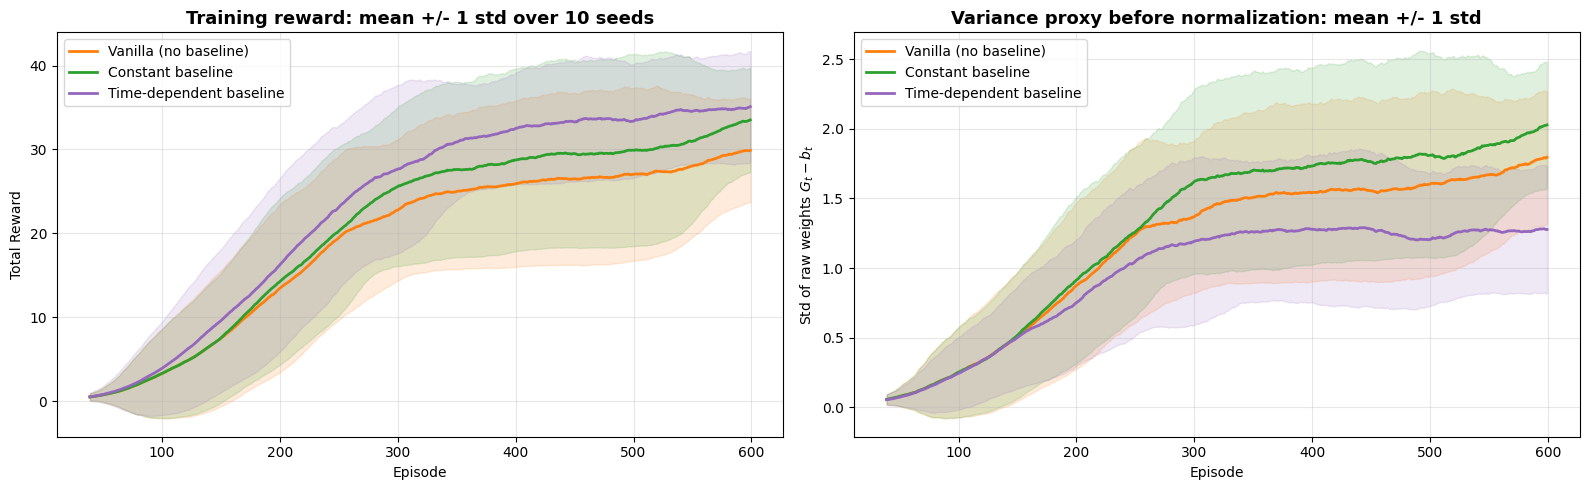

Final comparison across 10 seeds (last 50 episodes):
Vanilla (no baseline)    | reward:   29.7 +/-  6.2 | std(G-b):   1.78 +/- 0.48
Constant baseline        | reward:   33.3 +/-  6.3 | std(G-b):   2.01 +/- 0.45
Time-dependent baseline  | reward:   35.1 +/-  6.7 | std(G-b):   1.28 +/- 0.46

Interpretation:
- Constant baseline reduces variance a bit, but it ignores where we are in the episode.
- Time-dependent baseline usually reduces variance more because early and late timesteps have very different expected returns.
- Averaging across 10 seeds makes this conclusion much more reliable than a single lucky or unlucky run.
- The remaining gap motivates a learned state-dependent baseline V(s), which is Demo 7.


In [35]:
# Compare the baseline choices averaged over seeds
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
window = 40

# Left: reward curves averaged over seeds
ax = axes[0]
for label, result in baseline_results.items():
    plot_seed_average(
        ax,
        list(result['reward_histories_by_seed'].values()),
        color=result['color'],
        label=label,
        window=window,
    )
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Training reward: mean +/- 1 std over 10 seeds', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: variance proxy averaged over seeds
ax = axes[1]
for label, result in baseline_results.items():
    plot_seed_average(
        ax,
        list(result['adv_std_histories_by_seed'].values()),
        color=result['color'],
        label=label,
        window=window,
    )
ax.set_xlabel('Episode')
ax.set_ylabel('Std of raw weights $G_t - b_t$')
ax.set_title('Variance proxy before normalization: mean +/- 1 std', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Final comparison across 10 seeds (last 50 episodes):')
for label, result in baseline_results.items():
    reward_mean, reward_std = summarize_final_window(list(result['reward_histories_by_seed'].values()), tail=50)
    var_mean, var_std = summarize_final_window(list(result['adv_std_histories_by_seed'].values()), tail=50)
    print(f'{label:24s} | reward: {reward_mean:6.1f} +/- {reward_std:4.1f} | std(G-b): {var_mean:6.2f} +/- {var_std:4.2f}')

print('\nInterpretation:')
print('- Constant baseline reduces variance a bit, but it ignores where we are in the episode.')
print('- Time-dependent baseline usually reduces variance more because early and late timesteps have very different expected returns.')
print('- Averaging across 10 seeds makes this conclusion much more reliable than a single lucky or unlucky run.')
print('- The remaining gap motivates a learned state-dependent baseline V(s), which is Demo 7.')


---
## Demo 7: Learned state-dependent baseline (Actor-Critic)

Constant and time-dependent baselines help, but they still ignore the actual state. A better idea is to **learn** a baseline that depends on the current state:

$$
\nabla_\theta J(\theta) = \mathbb{E}\left[\sum_{t} \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot (G_t - b(s_t))\right]
$$

The standard choice is $b(s_t) = V^\pi(s_t)$, the **expected return from state $s_t$**. Then

$$A_t = G_t - V(s_t)$$

is the **advantage**: *"how much better was this action than what we'd expect from this state under the current policy?"*

This gives us the **Actor-Critic** architecture:
- **Actor** $\pi_\theta(a|s)$: the policy network (same as before)
- **Critic** $V_\phi(s)$: a value network that estimates expected return

The critic is trained by regression: minimize $(G_t - V_\phi(s_t))^2$.

Just like Demo 6, we average the training curves over **10 seeds** so the comparison is not driven by a single lucky or unlucky run.


In [36]:
# ============================================================
# REINFORCE with Baseline (Actor-Critic)
# ============================================================

class ValueNetwork(nn.Module):
    """Critic: estimates V(s)."""
    def __init__(self, obs_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, obs):
        return self.net(obs).squeeze(-1)


def train_actor_critic(env, n_episodes=500, gamma=0.99, lr_actor=3e-4,
                       lr_critic=1e-3, hidden=64, verbose=True, seed=None,
                       checkpoint_label=None, checkpoint_meta=None):
    """Train REINFORCE with learned baseline (actor-critic)."""
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    actor = GaussianPolicy(env.obs_dim, env.act_dim, hidden).to(device)
    critic = ValueNetwork(env.obs_dim, hidden).to(device)
    actor_opt = optim.Adam(actor.parameters(), lr=lr_actor)
    critic_opt = optim.Adam(critic.parameters(), lr=lr_critic)
    rewards_history = []
    adv_std_history = []

    t0 = time.time()
    for ep in range(n_episodes):
        obs = env.reset()
        log_probs = []
        rewards = []
        states = []

        while True:
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            action, log_prob = actor.get_action(obs_t)
            act_np = action.squeeze(0).cpu().detach().numpy()

            next_obs, reward, terminated, truncated, _ = env.step(act_np)
            log_probs.append(log_prob)
            rewards.append(reward)
            states.append(obs)
            obs = next_obs
            if terminated or truncated:
                break

        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns).to(device)

        states_t = torch.FloatTensor(np.array(states)).to(device)
        values = critic(states_t)

        advantages = returns - values.detach()
        adv_std_history.append(float(advantages.std().item()) if len(advantages) > 1 else 0.0)
        if len(advantages) > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        log_probs_t = torch.stack(log_probs).squeeze()
        actor_loss = -(log_probs_t * advantages).mean()

        actor_opt.zero_grad()
        actor_loss.backward()
        actor_opt.step()

        critic_loss = nn.functional.mse_loss(values, returns)

        critic_opt.zero_grad()
        critic_loss.backward()
        critic_opt.step()

        total_reward = sum(rewards)
        rewards_history.append(total_reward)

        if verbose and (ep + 1) % 100 == 0:
            avg = np.mean(rewards_history[-50:])
            std_val = actor.log_std.exp().mean().item()
            print(f'  Episode {ep+1:4d} | Avg reward: {avg:7.1f} | std: {std_val:.3f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')

    if checkpoint_label is not None:
        meta = {
            'obs_dim': int(env.obs_dim),
            'act_dim': int(env.act_dim),
            'hidden': int(hidden),
            'critic_hidden': int(hidden),
        }
        if checkpoint_meta:
            meta.update(checkpoint_meta)
        save_pg_checkpoint({
            'kind': 'actor_critic',
            'label': checkpoint_label,
            'meta': meta,
            'policy_state_dict': actor.state_dict(),
            'critic_state_dict': critic.state_dict(),
            'rewards': np.asarray(rewards_history, dtype=np.float32),
            'extras': {
                'adv_std_history': np.asarray(adv_std_history, dtype=np.float32),
            },
        })

    return actor, critic, rewards_history, adv_std_history


In [37]:
# ---------- Demo 7: Actor-Critic on the crawler ----------
print('=== Demo 7: Learned state-dependent baseline (Actor-Critic, 10 seeds) ===')
print(f'Actor: Gaussian policy (same architecture as Demo 5)')
print(f'Critic: value network V(s) as baseline')
print(f'Advantage: G_t - V(s_t) -- reduces variance!\n')

ac_seeds = compare_seeds
ac_episodes = compare_episodes
actor_critic_results = {
    'policies_by_seed': {},
    'critics_by_seed': {},
    'reward_histories_by_seed': {},
    'adv_std_histories_by_seed': {},
}

for seed in ac_seeds:
    env_ac = CrawlerEnv()
    actor_critic_meta = {
        'demo': '7',
        'variant': 'actor_critic',
        'seed': seed,
        'n_episodes': ac_episodes,
    }
    latest = maybe_load_pg_checkpoint(
        kind='actor_critic',
        obs_dim=env_ac.obs_dim,
        act_dim=env_ac.act_dim,
        hidden=64,
        label=f'Demo 7: Actor-Critic (seed {seed})',
        extra_meta=actor_critic_meta,
        with_critic=True,
    )
    if latest is None:
        print(f'  Seed {seed}: training')
        actor_seed, critic_seed, rewards_seed, adv_std_seed = train_actor_critic(
            env_ac,
            n_episodes=ac_episodes,
            lr_actor=3e-4,
            seed=seed,
            verbose=False,
            checkpoint_label=f'Demo 7: Actor-Critic (seed {seed})',
            checkpoint_meta=actor_critic_meta,
        )
    else:
        print(f'  Seed {seed}: loaded')
        actor_seed, critic_seed, rewards_seed, extras = latest
        adv_std_seed = list(extras.get('adv_std_history', []))

    actor_critic_results['policies_by_seed'][seed] = actor_seed
    actor_critic_results['critics_by_seed'][seed] = critic_seed
    actor_critic_results['reward_histories_by_seed'][seed] = rewards_seed
    actor_critic_results['adv_std_histories_by_seed'][seed] = adv_std_seed

actor_ac_seed = max(
    ac_seeds,
    key=lambda s: np.mean(actor_critic_results['reward_histories_by_seed'][s][-50:])
)
actor_ac = actor_critic_results['policies_by_seed'][actor_ac_seed]
critic_ac = actor_critic_results['critics_by_seed'][actor_ac_seed]
rewards_ac = actor_critic_results['reward_histories_by_seed'][actor_ac_seed]
adv_std_ac = actor_critic_results['adv_std_histories_by_seed'][actor_ac_seed]
print(f'Using seed {actor_ac_seed} as the representative Actor-Critic policy for rollout cells.')


=== Demo 7: Learned state-dependent baseline (Actor-Critic, 10 seeds) ===
Actor: Gaussian policy (same architecture as Demo 5)
Critic: value network V(s) as baseline
Advantage: G_t - V(s_t) -- reduces variance!

Loaded checkpoint for Demo 7: Actor-Critic (seed 0); skipping retraining.
  Seed 0: loaded
Loaded checkpoint for Demo 7: Actor-Critic (seed 1); skipping retraining.
  Seed 1: loaded
Loaded checkpoint for Demo 7: Actor-Critic (seed 2); skipping retraining.
  Seed 2: loaded
Loaded checkpoint for Demo 7: Actor-Critic (seed 3); skipping retraining.
  Seed 3: loaded
Loaded checkpoint for Demo 7: Actor-Critic (seed 4); skipping retraining.
  Seed 4: loaded
Loaded checkpoint for Demo 7: Actor-Critic (seed 5); skipping retraining.
  Seed 5: loaded
Loaded checkpoint for Demo 7: Actor-Critic (seed 6); skipping retraining.
  Seed 6: loaded
Loaded checkpoint for Demo 7: Actor-Critic (seed 7); skipping retraining.
  Seed 7: loaded
Loaded checkpoint for Demo 7: Actor-Critic (seed 8); skippin

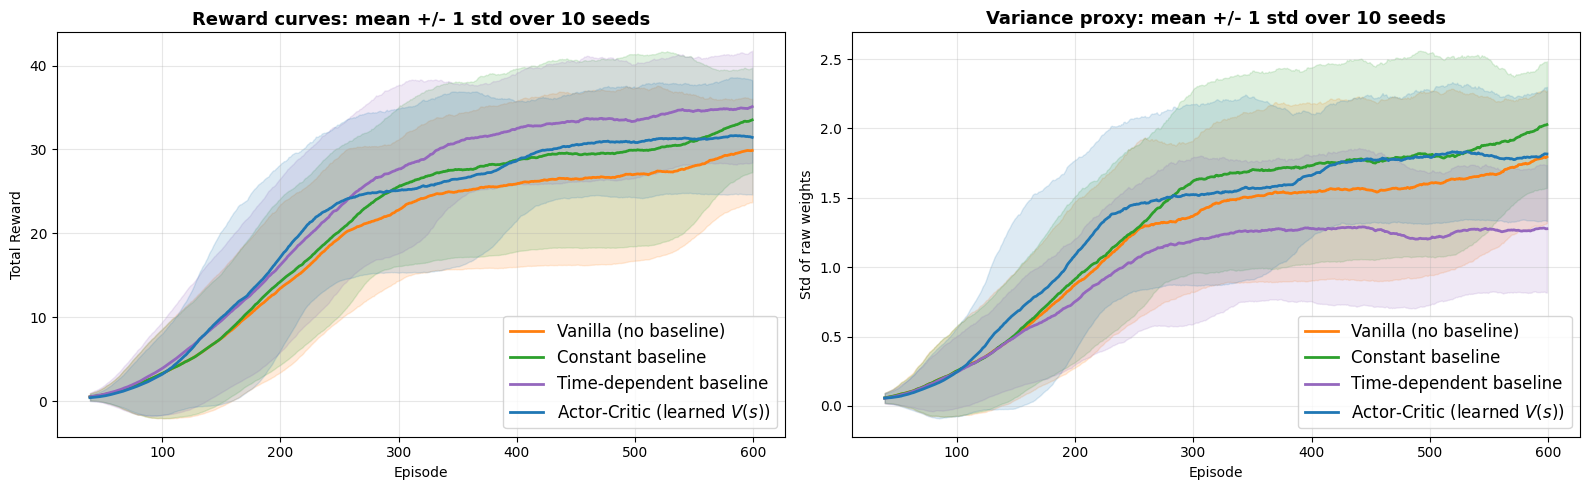

Final comparison across 10 seeds (last 50 episodes):
Vanilla (no baseline)    | reward:   29.7 +/-  6.2 | std(G-b):   1.78 +/- 0.48
Constant baseline        | reward:   33.3 +/-  6.3 | std(G-b):   2.01 +/- 0.45
Time-dependent baseline  | reward:   35.1 +/-  6.7 | std(G-b):   1.28 +/- 0.46
Actor-Critic (learned)   | reward:   31.5 +/-  6.9 | std(G-b):   1.80 +/- 0.47


In [38]:
# Side-by-side: all baseline choices plus Actor-Critic averaged over 10 seeds
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
window = 40

# Left: reward curves
ax = axes[0]
for label, result in baseline_results.items():
    plot_seed_average(
        ax,
        list(result['reward_histories_by_seed'].values()),
        color=result['color'],
        label=label,
        window=window,
    )
plot_seed_average(
    ax,
    list(actor_critic_results['reward_histories_by_seed'].values()),
    color='tab:blue',
    label='Actor-Critic (learned $V(s)$)',
    window=window,
)
ax.set_title('Reward curves: mean +/- 1 std over 10 seeds', fontsize=13, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Right: variance proxy comparison
ax = axes[1]
for label, result in baseline_results.items():
    plot_seed_average(
        ax,
        list(result['adv_std_histories_by_seed'].values()),
        color=result['color'],
        label=label,
        window=window,
    )
plot_seed_average(
    ax,
    list(actor_critic_results['adv_std_histories_by_seed'].values()),
    color='tab:blue',
    label='Actor-Critic (learned $V(s)$)',
    window=window,
)
ax.set_xlabel('Episode')
ax.set_ylabel('Std of raw weights')
ax.set_title('Variance proxy: mean +/- 1 std over 10 seeds', fontsize=13, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Final comparison across 10 seeds (last 50 episodes):')
for label, result in baseline_results.items():
    reward_mean, reward_std = summarize_final_window(list(result['reward_histories_by_seed'].values()), tail=50)
    var_mean, var_std = summarize_final_window(list(result['adv_std_histories_by_seed'].values()), tail=50)
    print(f'{label:24s} | reward: {reward_mean:6.1f} +/- {reward_std:4.1f} | std(G-b): {var_mean:6.2f} +/- {var_std:4.2f}')

ac_reward_mean, ac_reward_std = summarize_final_window(list(actor_critic_results['reward_histories_by_seed'].values()), tail=50)
ac_var_mean, ac_var_std = summarize_final_window(list(actor_critic_results['adv_std_histories_by_seed'].values()), tail=50)
print(f"{'Actor-Critic (learned)':24s} | reward: {ac_reward_mean:6.1f} +/- {ac_reward_std:4.1f} | std(G-b): {ac_var_mean:6.2f} +/- {ac_var_std:4.2f}")


In [39]:
# 10-second rollout of the Actor-Critic policy
env_eval_ac = CrawlerEnv()

def ac_policy(obs):
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        mu, _ = actor_ac(obs_t)
        return mu.squeeze(0).cpu().numpy()

frames_ac, dist_ac, _ = eval_policy(env_eval_ac, ac_policy, 'Demo 7: Actor-Critic')
show_video(frames_ac, title=f'Actor-Critic — {dist_ac:.2f}m in 10s')

Demo 7: Actor-Critic: traveled 0.84m in 10s  (episode reward: 41.8)


---
## Final Comparison

Let's see all methods side-by-side: how far does the crawler get in 10 seconds?

In [61]:
# ============================================================
# Final comparison: all methods, same crawler, 10 seconds
# ============================================================
from io import BytesIO
import base64

policy_panels = []
comparison_results = {}

def add_policy_panel(label, policy_fn, *, env=None, video_title=None, max_steps=500,
                     frames=None, dist=None):
    if frames is None or dist is None:
        if env is None:
            env = CrawlerEnv(max_steps=max_steps)
        frames, dist, _ = eval_policy(env, policy_fn, label, max_steps=max_steps)
    comparison_results[label] = dist
    video_html = show_video(frames, title=video_title or f'{label} — {dist:.2f}m in 10s').data
    policy_panels.append({
        'label': label,
        'distance': dist,
        'video_html': video_html,
    })

def representative_seed(history_dict):
    return max(history_dict, key=lambda s: np.mean(history_dict[s][-50:]))

def make_comparison_plot_base64(results_dict, title='Policy Comparison: Distance Traveled in 10s'):
    labels = list(results_dict.keys())
    dists = list(results_dict.values())
    colors = ['#d9534f' if d < 0.5 else '#5bc0de' if d < 1.5 else '#5cb85c' for d in dists]
    fig, ax = plt.subplots(figsize=(9, max(4, len(labels) * 0.55 + 1.2)))
    bars = ax.barh(labels, dists, color=colors, edgecolor='white', height=0.6)
    ax.set_xlabel('Distance (m)')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='gray', linewidth=0.5)
    for bar, d in zip(bars, dists):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{d:.2f}m', va='center', fontsize=11)
    ax.invert_yaxis()
    plt.tight_layout()
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=160, bbox_inches='tight')
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode('ascii')

# Current notebook policies
def reinforce_policy(obs):
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        mu, _ = policy_reinforce(obs_t)
        return mu.squeeze(0).cpu().numpy()

const_seed = representative_seed(baseline_results['Constant baseline']['reward_histories_by_seed'])
const_policy_model = baseline_results['Constant baseline']['policies_by_seed'][const_seed]
def constant_baseline_policy(obs):
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        mu, _ = const_policy_model(obs_t)
        return mu.squeeze(0).cpu().numpy()

time_seed = representative_seed(baseline_results['Time-dependent baseline']['reward_histories_by_seed'])
time_policy_model = baseline_results['Time-dependent baseline']['policies_by_seed'][time_seed]
def time_baseline_policy(obs):
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        mu, _ = time_policy_model(obs_t)
        return mu.squeeze(0).cpu().numpy()

def actor_critic_policy(obs):
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        mu, _ = actor_ac(obs_t)
        return mu.squeeze(0).cpu().numpy()

if 'frames_pg' in globals() and 'dist_pg' in globals():
    add_policy_panel('Demo 5: REINFORCE', reinforce_policy,
                     video_title='REINFORCE', frames=frames_pg, dist=dist_pg)
else:
    add_policy_panel('Demo 5: REINFORCE', reinforce_policy, video_title='REINFORCE')
add_policy_panel('Demo 6: Constant baseline', constant_baseline_policy, video_title='Constant baseline')
add_policy_panel('Demo 6: Time baseline', time_baseline_policy, video_title='Time-dependent baseline')
if 'frames_ac' in globals() and 'dist_ac' in globals():
    add_policy_panel('Demo 7: Actor-Critic', actor_critic_policy,
                     video_title='Actor-Critic', frames=frames_ac, dist=dist_ac)
else:
    add_policy_panel('Demo 7: Actor-Critic', actor_critic_policy, video_title='Actor-Critic')

# Load reusable policies exported from L6-1
policy_dir = Path('saved_policies')
tabular_path = policy_dir / 'tabular_q_2d.pt'
dqn_path = policy_dir / 'dqn_crawler_4act.pt'

if tabular_path.exists():
    tabular_ckpt = torch.load(tabular_path, map_location='cpu', weights_only=False)
    tabular_Q = np.asarray(tabular_ckpt['Q'])
    tabular_n_bins = int(tabular_ckpt['n_bins'])
    angle_lo = float(tabular_ckpt['angle_lo'])
    angle_hi = float(tabular_ckpt['angle_hi'])
    tabular_actions = {int(k): np.asarray(v, dtype=np.float32) for k, v in tabular_ckpt['action_map'].items()}
    def discretize_2d_obs(obs):
        def _bin(val, lo, hi):
            val = np.clip(val, lo, hi)
            idx = int((val - lo) / (hi - lo) * tabular_n_bins)
            return min(idx, tabular_n_bins - 1)
        return (_bin(obs[0], angle_lo, angle_hi), _bin(obs[1], angle_lo, angle_hi))
    def loaded_tabular_policy(obs):
        state = discretize_2d_obs(obs)
        action = int(np.argmax(tabular_Q[state]))
        return tabular_actions[action]
    add_policy_panel('L6-1: Tabular Q (2D)', loaded_tabular_policy, video_title='Loaded Tabular Q (2D)')
else:
    print(f'Skipping L6-1 tabular policy: {tabular_path} not found')

if dqn_path.exists():
    dqn_ckpt = torch.load(dqn_path, map_location='cpu', weights_only=False)
    dqn_model = QNetwork(dqn_ckpt['obs_dim'], dqn_ckpt['n_actions'], hidden=dqn_ckpt.get('hidden', 64)).to(device)
    dqn_model.load_state_dict(dqn_ckpt['q_net_state_dict'])
    dqn_model.eval()
    dqn_actions = {int(k): np.asarray(v, dtype=np.float32) for k, v in dqn_ckpt['action_map'].items()}
    def loaded_dqn_policy(obs):
        with torch.no_grad():
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            q_vals = dqn_model(obs_t)
            action = q_vals.argmax(dim=1).item()
            return dqn_actions[action]
    add_policy_panel('L6-1: DQN (4 actions)', loaded_dqn_policy, video_title='Loaded DQN (4 actions)')
else:
    print(f'Skipping L6-1 DQN policy: {dqn_path} not found')

plot_png = make_comparison_plot_base64(comparison_results)
cards_html = ''.join(
    f"<div style='background:#fff;border:1px solid #ddd;border-radius:10px;padding:10px;'>"
    f"<div style='font-weight:600;margin-bottom:8px'>{panel['label']} ({panel['distance']:.2f}m)</div>"
    f"{panel['video_html']}"
    f"</div>"
    for panel in policy_panels
)
display(HTML(
    f"""
<div style='display:grid;grid-template-columns:minmax(340px, 420px) 1fr;gap:20px;align-items:start;'>
  <div style='background:#fff;border:1px solid #ddd;border-radius:10px;padding:12px;'>
    <div style='font-weight:700;font-size:18px;margin-bottom:10px;'>Distance traveled in 10 seconds</div>
    <img src='data:image/png;base64,{plot_png}' style='width:100%;height:auto;display:block;' />
  </div>
  <div style='display:flex;flex-direction:column;gap:16px;'>
    {cards_html}
  </div>
</div>
"""
))

Demo 6: Constant baseline: traveled 1.28m in 10s  (episode reward: 64.0)
Demo 6: Time baseline: traveled 1.10m in 10s  (episode reward: 55.0)
L6-1: Tabular Q (2D): traveled 0.85m in 10s  (episode reward: 42.7)


NameError: name 'QNetwork' is not defined

---
## Summary

| Method | Actions | Key Property | Limitation |
|--------|---------|--------------|------------|
| **REINFORCE (no baseline)** | 2D continuous | Direct policy gradient | Highest variance |
| **+ constant baseline** | 2D continuous | Simple variance reduction | Ignores time and state |
| **+ time-dependent baseline** | 2D continuous | Better variance reduction | Still ignores state |
| **Actor-Critic** | 2D continuous | Learned state-dependent baseline | Can get unstable with large networks |

**What we showed:**
1. **REINFORCE handles continuous actions natively** — no discretization, no argmax
2. **Baselines reduce variance inside a single run** by replacing $G_t$ with $G_t - b_t$
3. **A time-dependent baseline helps more than a constant baseline** on this crawler
4. **A learned $V(s)$ baseline gives Actor-Critic** and usually the strongest variance reduction

**What comes next (Lecture 2):**
- We will connect policy gradients to **motion imitation**: track a reference motion instead of learning locomotion from scratch
- **DeepMimic** is the key example: transfer motion from human demonstrations to simulated characters and robot-like bodies
- This is one of the main foundations behind the acrobatic robot motion you have been seeing today
- We will focus on why **imitation rewards, reference trajectories, and simulator choice** matter for making that transfer work